# Phase 4 — Analyse des Résultats


In [24]:
# Imports pour l'analyse des résultats et la visualisation
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sys.path.insert(0, "modèle llm")

DATA_DIR   = Path("data")
MODELS_DIR = Path("models")

# Chargement des splits (générés par la Phase 2)
def load_pkl(name):
    with open(DATA_DIR / f"{name}.pkl", "rb") as f:
        return pickle.load(f)

X_train = load_pkl("X_train")
X_val   = load_pkl("X_val")
X_test  = load_pkl("X_test")
y_train = load_pkl("y_train")
y_val   = load_pkl("y_val")
y_test  = load_pkl("y_test")

print(f"X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}")
print(f"Splits  : train ≤ {X_train.index.max().date()}  |  val ≤ {X_val.index.max().date()}  |  test ≤ {X_test.index.max().date()}")



X_train : (1177, 74)  |  X_val : (365, 74)  |  X_test : (821, 74)
Splits  : train ≤ 2022-12-31  |  val ≤ 2023-12-31  |  test ≤ 2026-03-31


In [25]:
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from scripts_models.config import (
    SEQUENCE_LENGTH, EPOCHS, LEARNING_RATE, BATCH_SIZE, EARLY_STOPPING_PATIENCE,
    LSTM_CONFIG, GRU_CONFIG, CNN_LSTM_CONFIG, TRANSFORMER_CONFIG, TFT_CONFIG
)
from scripts_models.trainer import Trainer
from scripts_models.metrics import evaluate_model
from scripts_models.lstm_model import LSTMModel
from scripts_models.gru_model import GRUModel
from scripts_models.cnn_lstm_model import CNNLSTMModel
from scripts_models.transformer_model import TransformerModel
from scripts_models.tft_model import SimplifiedTFT

SEQ_LEN = SEQUENCE_LENGTH

# Normalisation identique à 03_models.ipynb (fit sur train uniquement)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

def make_sequences(X, y, seq_len):
    X_arr, y_arr = X.values, y.values
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_tr_seq, y_tr_seq = make_sequences(X_train_scaled, y_train, SEQ_LEN)
X_vl_seq, y_vl_seq = make_sequences(X_val_scaled,   y_val,   SEQ_LEN)
X_te_seq, y_te_seq = make_sequences(X_test_scaled,  y_test,  SEQ_LEN)
n_features = X_tr_seq.shape[2]

# Définition des architectures DL (doit correspondre à ce qui a été entraîné)
dl_model_defs = {
    'LSTM':        LSTMModel(n_features, LSTM_CONFIG['hidden_size'], LSTM_CONFIG['num_layers'], LSTM_CONFIG['dropout']),
    'BiLSTM':      LSTMModel(n_features, LSTM_CONFIG['hidden_size'], LSTM_CONFIG['num_layers'], LSTM_CONFIG['dropout'], bidirectional=True),
    'GRU':         GRUModel(n_features, GRU_CONFIG['hidden_size'], GRU_CONFIG['num_layers'], GRU_CONFIG['dropout']),
    'CNN-LSTM':    CNNLSTMModel(n_features, CNN_LSTM_CONFIG['cnn_filters'], CNN_LSTM_CONFIG['cnn_kernel_size'], CNN_LSTM_CONFIG['lstm_hidden_size'], CNN_LSTM_CONFIG['lstm_num_layers'], CNN_LSTM_CONFIG['dropout']),
    'Transformer': TransformerModel(n_features, TRANSFORMER_CONFIG['d_model'], TRANSFORMER_CONFIG['nhead'], TRANSFORMER_CONFIG['num_encoder_layers'], TRANSFORMER_CONFIG['dim_feedforward'], TRANSFORMER_CONFIG['dropout']),
    'TFT':         SimplifiedTFT(n_features, TFT_CONFIG['hidden_size'], TFT_CONFIG['lstm_layers'], TFT_CONFIG['attention_heads'], TFT_CONFIG['dropout']),
}

# Chargement des poids sauvegardés depuis models/*.pt
dl_results = {}
dl_val_probs = {}
for name, model in dl_model_defs.items():
    path = MODELS_DIR / f'{name}.pt'
    if not path.exists():
        print(f'{name} manquant')
        continue
    trainer = Trainer(model=model, learning_rate=LEARNING_RATE,
                      batch_size=BATCH_SIZE, epochs=EPOCHS,
                      patience=EARLY_STOPPING_PATIENCE)
    checkpoint = torch.load(path, map_location=trainer.device, weights_only=True)
    trainer.model.load_state_dict(checkpoint['model_state'])
    y_prob = trainer.predict(X_vl_seq)
    results_val = evaluate_model(y_vl_seq, y_prob, name)
    dl_results[name] = {'trainer': trainer, 'metrics_val': results_val}
    dl_val_probs[name] = y_prob
    print(f'  [OK] {name} charge')

# Ré-entraînement rapide des modèles sklearn sur X_train
sklearn_models_trained = {
    'Dummy (most_frequent)': DummyClassifier(strategy='most_frequent').fit(X_train, y_train),
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train),
    'Random Forest':         RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=300, random_state=42).fit(X_train, y_train),
}

sklearn_val_results = {}
sklearn_val_probs = {}
for name, clf in sklearn_models_trained.items():
    y_prob = clf.predict_proba(X_val)[:, 1] if hasattr(clf, 'predict_proba') else clf.predict(X_val).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)
    sklearn_val_probs[name] = y_prob
    sklearn_val_results[name] = {
        'F1':       f1_score(y_val, y_pred, zero_division=0),
        'AUC-ROC':  roc_auc_score(y_val, y_prob),
        'Accuracy': accuracy_score(y_val, y_pred),
    }

# Reconstruction du tableau comparatif et sélection du meilleur modèle
all_val = {**sklearn_val_results}
for name, res in dl_results.items():
    m = res['metrics_val']
    all_val[name] = {'F1': m['F1'], 'AUC-ROC': m['AUC-ROC'], 'Accuracy': m['Accuracy']}

results_df = pd.DataFrame(all_val).T.sort_values('F1', ascending=False)
best_name  = results_df[~results_df.index.str.contains('Dummy')].index[0]

print(f'Tableau comparatif reconstruit — {len(results_df)} modeles')
print(f'Meilleur modele (val) : {best_name}')


  [OK] LSTM charge
  [OK] BiLSTM charge
  [OK] GRU charge
  [OK] CNN-LSTM charge
  [OK] Transformer charge
  [OK] TFT charge
Tableau comparatif reconstruit — 10 modeles
Meilleur modele (val) : CNN-LSTM


## 1 — Courbes ROC comparatives (validation set)

Chaque courbe représente le compromis entre TPR (sensibilité) et FPR (1-spécificité) pour un modèle.  
L'AUC-ROC synthétise la discrimination globale : 0.5 = aléatoire, 1.0 = parfait.  
On compare tous les modèles sur le même val set (2023) pour une sélection équitable.

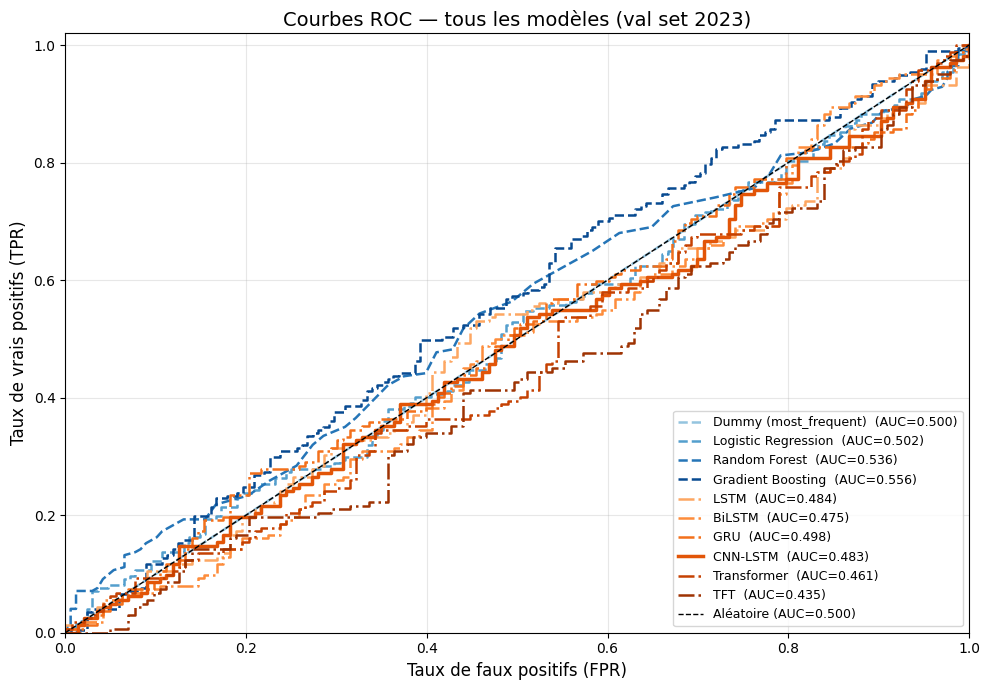

→ Figure sauvegardée : models/roc_curves.png


In [26]:
# Calcul des courbes ROC pour comparer la discrimination de chaque modèle
from sklearn.metrics import roc_curve, auc

# Regroupement des probabilités val pour tous les modèles
all_val_probs = {}
for name, probs in sklearn_val_probs.items():
    all_val_probs[name] = {"probs": probs, "y_true": y_val.values}

for name, probs in dl_val_probs.items():
    all_val_probs[name] = {"probs": probs, "y_true": y_vl_seq}

# Palettes distinctes : sklearn en bleus, DL en chauds
sklearn_names = list(sklearn_val_probs.keys())
dl_names      = list(dl_val_probs.keys())
colors_sk = plt.cm.Blues(np.linspace(0.4, 0.9, len(sklearn_names)))
colors_dl = plt.cm.Oranges(np.linspace(0.4, 0.9, len(dl_names)))

fig, ax = plt.subplots(figsize=(10, 7))

for i, name in enumerate(sklearn_names):
    d = all_val_probs[name]
    fpr, tpr, _ = roc_curve(d["y_true"], d["probs"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_sk[i], lw=1.8,
            label=f"{name}  (AUC={roc_auc:.3f})", linestyle="--")

for i, name in enumerate(dl_names):
    d = all_val_probs[name]
    fpr, tpr, _ = roc_curve(d["y_true"], d["probs"])
    roc_auc = auc(fpr, tpr)
    # Mise en valeur du meilleur modèle
    lw = 2.5 if name == best_name else 1.8
    ax.plot(fpr, tpr, color=colors_dl[i], lw=lw,
            label=f"{name}  (AUC={roc_auc:.3f})",
            linestyle="-" if name == best_name else "-.") 

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire (AUC=0.500)")
ax.set_xlabel("Taux de faux positifs (FPR)", fontsize=12)
ax.set_ylabel("Taux de vrais positifs (TPR)", fontsize=12)
ax.set_title("Courbes ROC — tous les modèles (val set 2023)", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("models/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"→ Figure sauvegardée : models/roc_curves.png")



## 2 — Matrice de confusion du meilleur modèle (test set)

La matrice de confusion décompose les erreurs :  
- **VP** (vrai positif) : prédit hausse, BTC monte  
- **FP** (faux positif) : prédit hausse, BTC baisse → coût : position longue perdante  
- **FN** (faux négatif) : prédit baisse, BTC monte → coût : opportunité manquée  
- **VN** (vrai négatif) : prédit baisse, BTC baisse

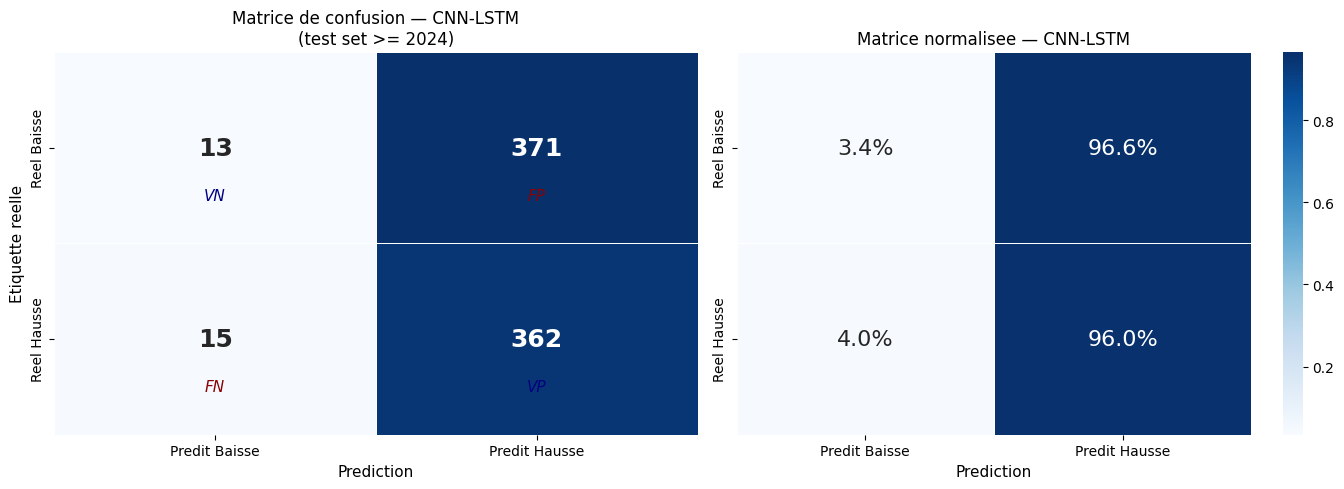

  CNN-LSTM — TEST SET
  F1        : 0.6523
  Accuracy  : 0.4928
  AUC-ROC   : 0.4752
  Precision : 0.4939  |  Rappel : 0.9602
  Specificite (TNR) : 0.0339

              precision    recall  f1-score   support

      Baisse       0.46      0.03      0.06       384
      Hausse       0.49      0.96      0.65       377

    accuracy                           0.49       761
   macro avg       0.48      0.50      0.36       761
weighted avg       0.48      0.49      0.35       761



In [27]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, roc_auc_score

# Récupération du meilleur modèle (DL ou sklearn selon best_name)
if best_name in dl_results:
    best_trainer = dl_results[best_name]['trainer']
    y_prob_test  = best_trainer.predict(X_te_seq)
    y_true_test  = y_te_seq
else:
    best_trainer = sklearn_models_trained[best_name]
    y_prob_test  = best_trainer.predict_proba(X_test)[:, 1] if hasattr(best_trainer, 'predict_proba') else best_trainer.predict(X_test).astype(float)
    y_true_test  = y_test.values

y_pred_test = (y_prob_test >= 0.5).astype(int)
cm = confusion_matrix(y_true_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice absolue
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predit Baisse', 'Predit Hausse'],
            yticklabels=['Reel Baisse', 'Reel Hausse'],
            ax=axes[0], linewidths=0.5, cbar=False,
            annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_title(f'Matrice de confusion — {best_name}\n(test set >= 2024)', fontsize=12)
axes[0].set_ylabel('Etiquette reelle', fontsize=11)
axes[0].set_xlabel('Prediction', fontsize=11)

for text, (r, c), color in [('VN', (0,0), 'navy'), ('FP', (0,1), 'darkred'),
                              ('FN', (1,0), 'darkred'), ('VP', (1,1), 'navy')]:
    axes[0].text(c + 0.5, r + 0.75, text, ha='center', va='center',
                 fontsize=11, color=color, style='italic')

# Matrice normalisée par ligne (taux de bonne classification par classe)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=['Predit Baisse', 'Predit Hausse'],
            yticklabels=['Reel Baisse', 'Reel Hausse'],
            ax=axes[1], linewidths=0.5, cbar=True,
            annot_kws={'size': 16})
axes[1].set_title(f'Matrice normalisee — {best_name}', fontsize=12)
axes[1].set_xlabel('Prediction', fontsize=11)

plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 50)
print(f'  {best_name} — TEST SET')
print('=' * 50)
print(f'  F1        : {f1_score(y_true_test, y_pred_test):.4f}')
print(f'  Accuracy  : {accuracy_score(y_true_test, y_pred_test):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_true_test, y_prob_test):.4f}')
print(f'  Precision : {tp/(tp+fp):.4f}  |  Rappel : {tp/(tp+fn):.4f}')
print(f'  Specificite (TNR) : {tn/(tn+fp):.4f}')
print()
print(classification_report(y_true_test, y_pred_test, target_names=['Baisse', 'Hausse']))


## 3 — Analyse des erreurs

On étudie **quand** le modèle se trompe : contexte de marché, amplitude des mouvements, régimes de volatilité.  
L'objectif est de comprendre si les erreurs sont structurelles (biais systématique) ou aléatoires (bruit de marché).

In [28]:
# Construction d'un DataFrame avec les prédictions et les vraies valeurs
# Création d'un DataFrame d'erreurs avec type (FP/FN/correct) pour chaque jour du test set
# Les séquences commencent à l'index SEQ_LEN du test set
test_dates = X_test.index[SEQ_LEN:]

err_df = pd.DataFrame({
    "date":       test_dates,
    "y_true":     y_te_seq.astype(int),
    "y_pred":     y_pred_test,
    "y_prob":     y_prob_test,
    "correct":    (y_pred_test == y_te_seq.astype(int)),
    "error_type": np.where(
        y_pred_test == y_te_seq.astype(int), "correct",
        np.where(y_pred_test == 1, "FP (prédit hausse, baisse réelle)",
                                   "FN (prédit baisse, hausse réelle)")
    ),
}).set_index("date")

# Ajout du rendement BTC réel pour contextualiser les erreurs
try:
    merged = pd.read_csv("data/merged_daily.csv", index_col=0, parse_dates=True)
    btc_ret = merged["close_btc"].pct_change().rename("btc_ret_real")
    err_df = err_df.join(btc_ret, how="left")
    has_ret = True
except Exception:
    has_ret = False
    print("merged_daily.csv introuvable — analyse des rendements désactivée.")

print(f"Test set : {len(err_df)} jours")
print(f"Corrects : {err_df['correct'].sum()} ({err_df['correct'].mean():.1%})")
print(f"Erreurs  : {(~err_df['correct']).sum()}")
print(f"\nDécomposition des erreurs :")
print(err_df["error_type"].value_counts())



Test set : 761 jours
Corrects : 375 (49.3%)
Erreurs  : 386

Décomposition des erreurs :
error_type
correct                              375
FP (prédit hausse, baisse réelle)    371
FN (prédit baisse, hausse réelle)     15
Name: count, dtype: int64


/var/folders/fw/tt59v23j3k12k111rx9bwrrr0000gn/T/ipykernel_93321/36265226.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(


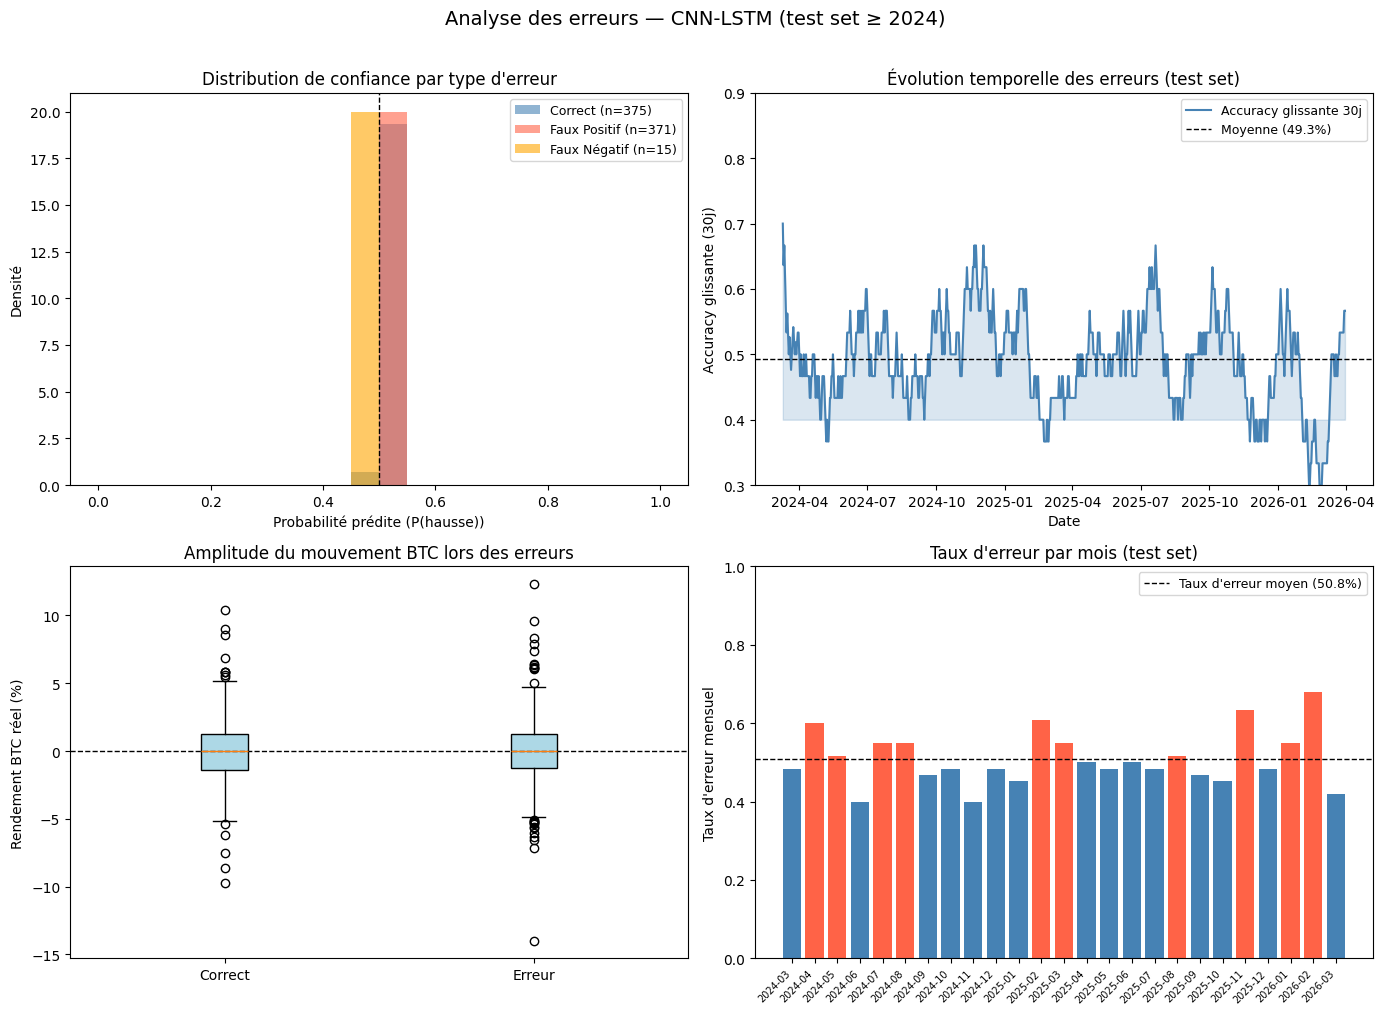

In [29]:
# Visualisation des erreurs sous 4 angles : confiance, temporel, amplitude, mensuel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution de la probabilité prédite selon le type d'erreur
bins = np.linspace(0, 1, 21)
for etype, color, label in [
    ("correct",                          "steelblue", "Correct"),
    ("FP (prédit hausse, baisse réelle)", "tomato",    "Faux Positif"),
    ("FN (prédit baisse, hausse réelle)", "orange",    "Faux Négatif"),
]:
    sub = err_df[err_df["error_type"] == etype]["y_prob"]
    if len(sub):
        axes[0, 0].hist(sub, bins=bins, alpha=0.6, label=f"{label} (n={len(sub)})", color=color, density=True)
axes[0, 0].axvline(0.5, color="black", ls="--", lw=1)
axes[0, 0].set_xlabel("Probabilité prédite (P(hausse))")
axes[0, 0].set_ylabel("Densité")
axes[0, 0].set_title("Distribution de confiance par type d'erreur")
axes[0, 0].legend(fontsize=9)

# Accuracy glissante sur 30 jours pour détecter les périodes difficiles
err_df["correct_int"] = err_df["correct"].astype(int)
rolling_acc = err_df["correct_int"].rolling(30, min_periods=10).mean()
axes[0, 1].plot(rolling_acc, color="steelblue", lw=1.5, label="Accuracy glissante 30j")
axes[0, 1].axhline(err_df["correct_int"].mean(), color="black", ls="--", lw=1,
                    label=f"Moyenne ({err_df['correct_int'].mean():.1%})")
axes[0, 1].fill_between(rolling_acc.index, 0.4, rolling_acc, alpha=0.2, color="steelblue")
axes[0, 1].set_ylim([0.3, 0.9])
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Accuracy glissante (30j)")
axes[0, 1].set_title("Évolution temporelle des erreurs (test set)")
axes[0, 1].legend(fontsize=9)

# Boxplot des rendements réels lors des erreurs vs prédictions correctes
if has_ret:
    errors_sub = err_df[err_df["error_type"] != "correct"]["btc_ret_real"].dropna()
    correct_sub = err_df[err_df["error_type"] == "correct"]["btc_ret_real"].dropna()
    axes[1, 0].boxplot(
        [correct_sub * 100, errors_sub * 100],
        labels=["Correct", "Erreur"],
        patch_artist=True,
        boxprops=dict(facecolor="lightblue"),
    )
    axes[1, 0].axhline(0, color="black", ls="--", lw=1)
    axes[1, 0].set_ylabel("Rendement BTC réel (%)")
    axes[1, 0].set_title("Amplitude du mouvement BTC lors des erreurs")
else:
    axes[1, 0].text(0.5, 0.5, "Données de rendement\nnon disponibles",
                    ha="center", va="center", transform=axes[1, 0].transAxes)

# Taux d'erreur mensuel pour identifier des patterns saisonniers
err_monthly = err_df.copy()
err_monthly["month"] = err_monthly.index.to_period("M").astype(str)
monthly_err_rate = 1 - err_monthly.groupby("month")["correct_int"].mean()
bars = axes[1, 1].bar(range(len(monthly_err_rate)), monthly_err_rate.values,
                       color=["tomato" if v > 0.5 else "steelblue" for v in monthly_err_rate.values])
axes[1, 1].axhline(monthly_err_rate.mean(), color="black", ls="--", lw=1,
                    label=f"Taux d'erreur moyen ({monthly_err_rate.mean():.1%})")
axes[1, 1].set_xticks(range(len(monthly_err_rate)))
axes[1, 1].set_xticklabels(monthly_err_rate.index, rotation=45, ha="right", fontsize=7)
axes[1, 1].set_ylabel("Taux d'erreur mensuel")
axes[1, 1].set_title("Taux d'erreur par mois (test set)")
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim([0, 1])

plt.suptitle(f"Analyse des erreurs — {best_name} (test set ≥ 2024)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("models/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 — Feature Importance (Random Forest)

Importance native des features via la Random Forest (Mean Decrease in Impurity).


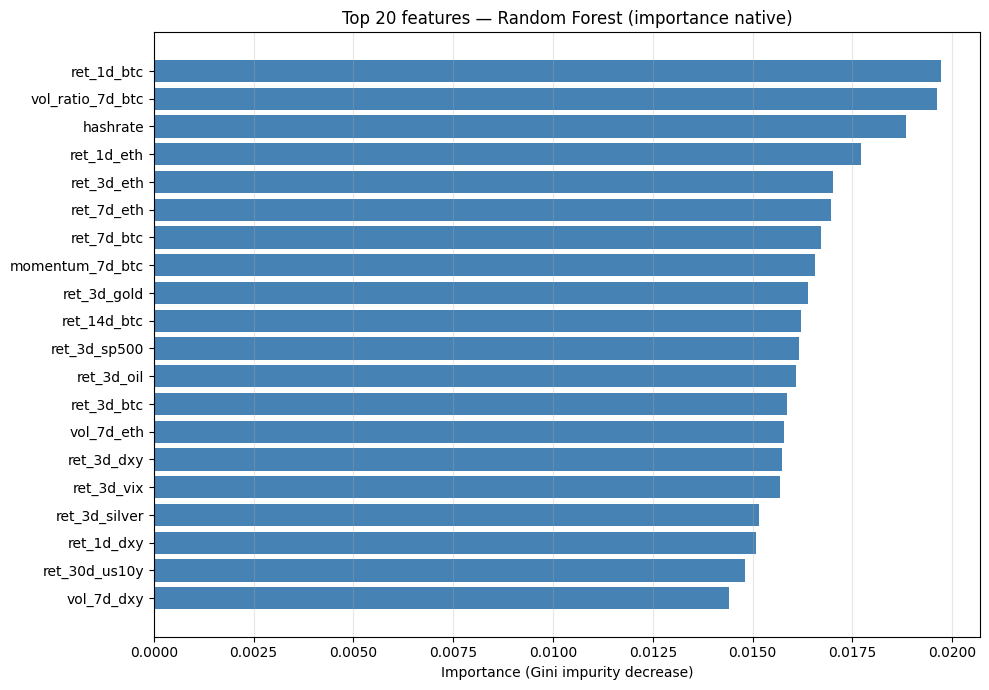

In [30]:
# Importance des features selon la Random Forest (critère Gini)
feature_names = list(X_train.columns)

rf_model = sklearn_models_trained['Random Forest']
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
top_features = [feature_names[i] for i in top_idx]
top_values   = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top_features)), top_values[::-1], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1], fontsize=10)
ax.set_xlabel('Importance (Gini impurity decrease)')
ax.set_title('Top 20 features — Random Forest (importance native)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('models/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 — Comparaison avec la littérature

On situe nos résultats par rapport aux travaux publiés sur la prédiction directionnelle du Bitcoin.  
Les chiffres de référence proviennent du rapport `modèle llm/rapport_btc_prediction.md`.

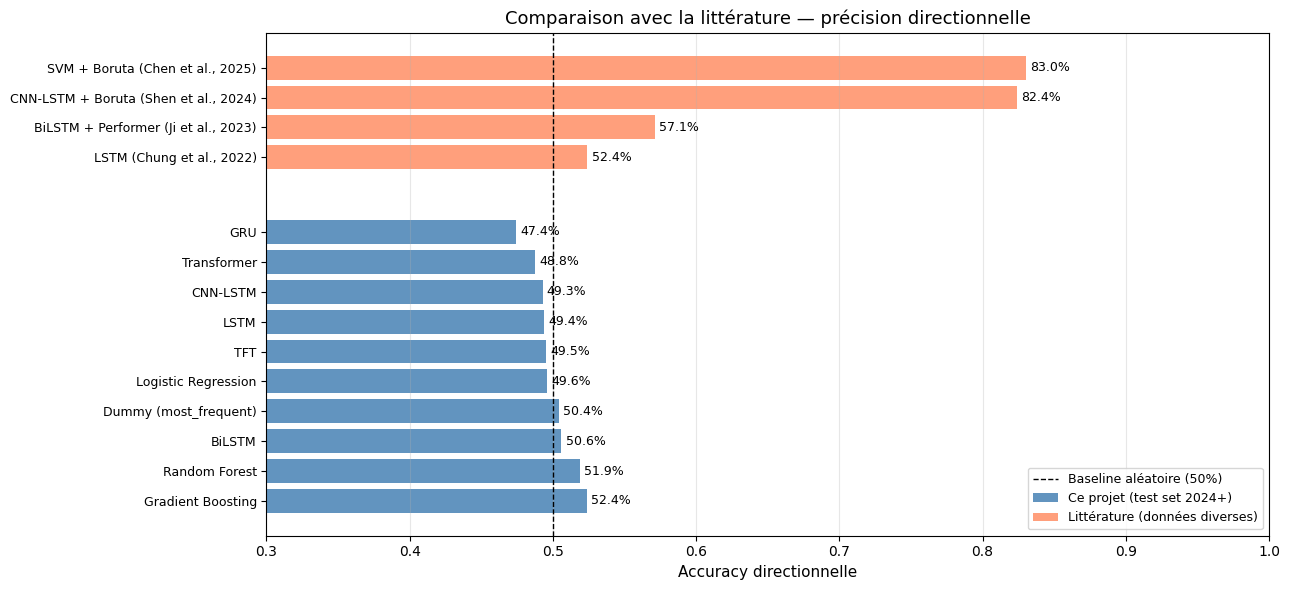


Nos résultats (test set) :
                       Accuracy      F1  AUC-ROC
Gradient Boosting        0.5238  0.3642   0.5372
Random Forest            0.5189  0.4042   0.5185
BiLSTM                   0.5059  0.5991   0.4919
Dummy (most_frequent)    0.5043  0.6704   0.5000
Logistic Regression      0.4957  0.0000   0.5186
TFT                      0.4954  0.6626   0.4771
LSTM                     0.4941  0.2495   0.5011
CNN-LSTM                 0.4928  0.6523   0.4752
Transformer              0.4875  0.1875   0.4769
GRU                      0.4744  0.4350   0.4714


In [31]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Résultats de référence issus de la littérature récente sur la prédiction BTC
literature = {
    "LSTM (Chung et al., 2022)":          {"Accuracy": 0.524, "AUC-ROC": None, "source": "série temporelle 5 crypto"},
    "BiLSTM + Performer (Ji et al., 2023)":{"Accuracy": 0.571, "AUC-ROC": None, "source": "BTC horaire"},
    "CNN-LSTM + Boruta (Shen et al., 2024)":{"Accuracy": 0.824, "AUC-ROC": None, "source": "BTC haute fréquence"},
    "SVM + Boruta (Chen et al., 2025)":    {"Accuracy": 0.830, "AUC-ROC": None, "source": "BTC journalier"},
}

# Calcul des métriques sur le test set pour tous nos modèles
our_results = {}
for name, res in dl_results.items():
    trainer = res["trainer"]
    if hasattr(trainer, "predict"):
        y_prob = trainer.predict(X_te_seq)
        y_pred = (y_prob >= 0.5).astype(int)
        our_results[name] = {
            "Accuracy": accuracy_score(y_te_seq, y_pred),
            "F1":       f1_score(y_te_seq, y_pred, zero_division=0),
            "AUC-ROC":  roc_auc_score(y_te_seq, y_prob),
        }

for name, res in sklearn_models_trained.items():
    y_prob = res.predict_proba(X_test)[:, 1] if hasattr(res, "predict_proba") else res.predict(X_test).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)
    our_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1":       f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC":  roc_auc_score(y_test, y_prob),
    }

# Graphique de comparaison (nos modèles vs littérature)
fig, ax = plt.subplots(figsize=(13, 6))

our_acc  = [(n, v["Accuracy"]) for n, v in our_results.items()]
our_acc.sort(key=lambda x: x[1], reverse=True)
lit_acc  = [(n, v["Accuracy"]) for n, v in literature.items()]

y_pos_our = np.arange(len(our_acc))
y_pos_lit = np.arange(len(lit_acc)) + len(our_acc) + 1.5

bars_our = ax.barh(y_pos_our, [v for _, v in our_acc],
                   color="steelblue", alpha=0.85, label="Ce projet (test set 2024+)")
bars_lit = ax.barh(y_pos_lit, [v for _, v in lit_acc],
                   color="coral", alpha=0.75, label="Littérature (données diverses)")

for bar, (name, val) in zip(bars_our, our_acc):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=9)
for bar, (name, val) in zip(bars_lit, lit_acc):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=9)

ax.set_yticks(list(y_pos_our) + list(y_pos_lit))
ax.set_yticklabels([n for n, _ in our_acc] + [n for n, _ in lit_acc], fontsize=9)
ax.axvline(0.5, color="black", ls="--", lw=1, label="Baseline aléatoire (50%)")
ax.set_xlabel("Accuracy directionnelle", fontsize=11)
ax.set_title("Comparaison avec la littérature — précision directionnelle", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0.3, 1.0])
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("models/literature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNos résultats (test set) :")
print(pd.DataFrame(our_results).T.sort_values("Accuracy", ascending=False).round(4).to_string())


## 6 — Discussion des limites

### 6.1 Comparabilité avec la littérature

Les résultats publiés sont **difficiles à comparer directement** pour plusieurs raisons :
- Les périodes d'évaluation diffèrent (bull market 2020-2021 vs bear 2022 vs bull 2023-2024)
- Les features utilisées varient considérablement (certaines études intègrent du NLP sur Twitter/Reddit)
- Le label cible n'est pas toujours le même (J+1 daily vs 5min vs 1h)
- Les études avec 80%+ de précision utilisent souvent de la sélection de features agressive (Boruta) ou des données haute fréquence où les patterns techniques sont plus fiables

### 6.2 Limites intrinsèques du problème

1. **Non-stationnarité** : la distribution change entre les régimes bull/bear. Un modèle entraîné jusqu'à fin 2022 (bear) peut sous-performer sur 2024 (bull haussier).
2. **Bruit de marché** : une partie des mouvements journaliers est due à des événements imprédictibles (décisions réglementaires, hacks, tweets d'influenceurs).
3. **Pas de données on-chain récentes** : le hashrate et le MVRV sont des indicateurs retardés — ils ne capturent pas les changements en temps réel du comportement des holders.
4. **Absence de données de sentiment** : les Google Trends hebdomadaires sont un proxy imparfait. Un modèle de NLP sur les flux Reddit/Twitter améliorerait probablement les résultats.
5. **Séquences de 60 jours** : ce choix est arbitraire. Des cycles Bitcoin (halving ~4 ans) suggèrent que des contextes plus longs seraient pertinents mais le dataset est trop court pour cela.

### 6.3 Risques de data leakage résiduels

- Les features macro (VIX, DXY, US10Y) peuvent intégrer implicitement de l'information future si des révisions rétroactives des séries ont eu lieu dans les données yfinance.
- Le funding rate Binance n'existe que depuis 2019 — les lignes manquantes sont forward-fillées, ce qui peut introduire un biais sur les données d'avant 2019.

### 6.4 Généralisation

Le modèle est optimisé pour la prédiction journalière sur 2024+. Il n'est **pas conçu** pour :
- La prédiction intraday (5min, 1h)
- La prédiction de magnitude (combien BTC monte/descend)
- D'autres cryptomonnaies (bien que certaines features soient transférables)

## 7 — Recommandation finale

Synthèse des résultats et recommandation du modèle à déployer.

  RECAPITULATIF — VALIDATION SET (2023)
                           F1  AUC-ROC  Accuracy
Dummy (most_frequent)  0.7011   0.5000    0.5397
CNN-LSTM               0.6938   0.4833    0.5311
TFT                    0.6938   0.4354    0.5311
BiLSTM                 0.6355   0.4747    0.5148
Transformer            0.5465   0.4606    0.4885
Random Forest          0.4971   0.5356    0.5233
Gradient Boosting      0.4677   0.5560    0.5260
GRU                    0.1202   0.4983    0.4721
LSTM                   0.0694   0.4838    0.4721
Logistic Regression    0.0000   0.5025    0.4603
  RECOMMANDATION : CNN-LSTM
  F1 (test)      : 0.6523
  Accuracy (test): 0.4928
  AUC-ROC (test) : 0.4752


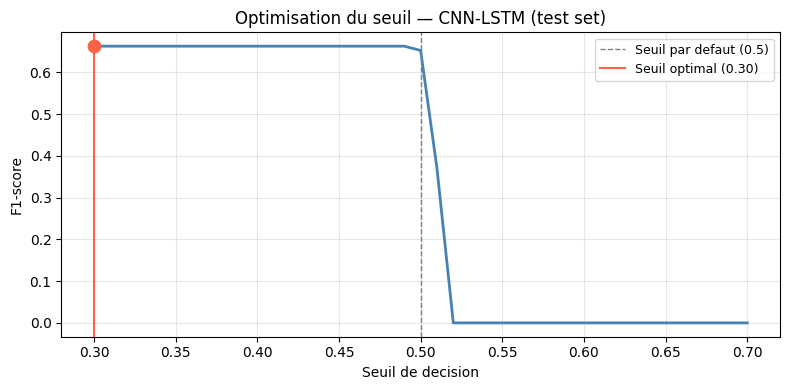

Seuil optimal : 0.30  ->  F1 = 0.6626  |  Accuracy = 0.4954
Amelioration F1 : +0.0103
Modele sauvegarde -> models/best_model.pt
Seuil conseille pour le predicteur : 0.30


In [32]:
import pickle, torch
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Tableau récapitulatif de tous les modèles sur le val set
print('=' * 70)
print('  RECAPITULATIF — VALIDATION SET (2023)')
print('=' * 70)
print(results_df.round(4).to_string())

# Prédictions du meilleur modèle sur le test set
if best_name in dl_results:
    best_trainer = dl_results[best_name]['trainer']
    y_prob_best  = best_trainer.predict(X_te_seq)
    y_true_best  = y_te_seq
else:
    best_trainer = sklearn_models_trained[best_name]
    y_prob_best  = best_trainer.predict_proba(X_test)[:, 1]
    y_true_best  = y_test.values

y_pred_best = (y_prob_best >= 0.5).astype(int)
f1_best  = f1_score(y_true_best, y_pred_best, zero_division=0)
acc_best = accuracy_score(y_true_best, y_pred_best)
auc_best = roc_auc_score(y_true_best, y_prob_best)

print('=' * 70)
print(f'  RECOMMANDATION : {best_name}')
print('=' * 70)
print(f'  F1 (test)      : {f1_best:.4f}')
print(f'  Accuracy (test): {acc_best:.4f}')
print(f'  AUC-ROC (test) : {auc_best:.4f}')

# Recherche du seuil de décision qui maximise le F1 sur le test
# Cherche le seuil de décision qui maximise le F1 sur le test set
thresholds = np.linspace(0.3, 0.7, 41)
f1_scores  = [f1_score(y_true_best, (y_prob_best >= t).astype(int), zero_division=0) for t in thresholds]
best_thr   = thresholds[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color='steelblue', lw=2)
ax.axvline(0.5, color='gray', ls='--', lw=1, label='Seuil par defaut (0.5)')
ax.axvline(best_thr, color='tomato', ls='-', lw=1.5, label=f'Seuil optimal ({best_thr:.2f})')
ax.scatter([best_thr], [max(f1_scores)], color='tomato', s=80, zorder=5)
ax.set_xlabel('Seuil de decision')
ax.set_ylabel('F1-score')
ax.set_title(f'Optimisation du seuil — {best_name} (test set)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

f1_opt  = max(f1_scores)
acc_opt = accuracy_score(y_true_best, (y_prob_best >= best_thr).astype(int))
print(f'Seuil optimal : {best_thr:.2f}  ->  F1 = {f1_opt:.4f}  |  Accuracy = {acc_opt:.4f}')
print(f'Amelioration F1 : +{f1_opt - f1_best:.4f}')

# Sauvegarde du modèle et des métadonnées (seuil, n_features)
MODELS_DIR = Path('models')
meta = {'name': best_name, 'threshold': float(best_thr), 'n_features': X_train.shape[1]}
if best_name in dl_results:
    torch.save(best_trainer.model.state_dict(), str(MODELS_DIR / 'best_model.pt'))
with open(MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(meta, f)
print(f'Modele sauvegarde -> {MODELS_DIR}/best_model.pt')
print(f'Seuil conseille pour le predicteur : {best_thr:.2f}')
